# Exploratory Data Analysis

As of Milestone 2, we have written logic for importing and cleaning the datasets we will use later on our models. This notebook will immediately follow that and take a look at what is actually in these files and what other information we can extract from them. We'll use Pandas to help visualize data.

In [17]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

# import and load config variables
from vgc_matchup_predictor.utils.config import load_config 
config = load_config()

If you are following this notebook in a cloned repository and the third line raises an error for you, you likely have not set up the repository as a package yet. This is an easy fix; after cloning the repository, generate a virtual environment and then you can set up the project package.

```
python -m venv <venv-name>
pip install -e .
```

The second command must be run while in the project root directory (`vgc-matchup-predictor/`). Once you are done, re-run the above cell.

In [ ]:
# run this cell to import and process the datasets

import vgc_matchup_predictor.data.download_hf
import vgc_matchup_predictor.data.process_json

vgc_matchup_predictor.data.download_hf.download_hf_dataset()
vgc_matchup_predictor.data.process_json.start_process_data()

We'll start by importing the JSON files for the raw data using `pandas.read_json()`.

In [5]:
raw_ma = pd.read_json('../' + config['dataset']['raw_path'] + config['dataset']['m_a'])
raw_ma

,gen9championsvgc2026regma-2600664326,gen9championsvgc2026regma-2600407331,gen9championsvgc2026regma-2600687109,gen9championsvgc2026regma-2600573325,gen9championsvgc2026regma-2600148740,gen9championsvgc2026regma-2600076680,gen9championsvgc2026regma-2599901451,gen9championsvgc2026regma-2600289444,gen9championsvgc2026regma-2599798141,gen9championsvgc2026regma-2599790190,...,gen9championsvgc2026regma-2626640937,gen9championsvgc2026regma-2628783151,gen9championsvgc2026regma-2625565884,gen9championsvgc2026regma-2627117078,gen9championsvgc2026regma-2631487825,gen9championsvgc2026regma-2632061873,gen9championsvgc2026regma-2631930665,gen9championsvgc2026regma-2623115146,gen9championsvgc2026regma-2624138171,gen9championsvgc2026regma-2622688383
0,1777827111,1777794779,1777829212,1777818212,1777761794,1777754577,1777738827,1777777666,1777727787,1777728962,...,1780789986,1781054927,1780660888,1780855747,1781391517,1781471826,1781457213,1780375586,1780496941,1780327929
1,|j|☆skarmbag\n|j|☆kicks10\n|html|<table width=...,|j|☆magicalarcher57\n|j|☆Ekiller12z\n|t:|17777...,"|raw|<div class=""broadcast-blue""><strong>This ...",|j|☆magicalarcher57\n|j|☆mynamegrassgreen\n|t:...,|j|☆lowk like dat\n|j|☆anchor orchestra\n|t:|1...,|j|☆hiyopon\n|j|☆JonnyNerd\n|t:|1777754359\n|g...,|j|☆djogoclao\n|j|☆mynamegrassgreen\n|html|<ta...,|j|☆AtumAsar\n|j|☆magicalarcher57\n|html|<tabl...,|j|☆AragonVGC\n|j|☆goodbye brede\n|html|<table...,|j|☆treehuggingbunny\n|j|☆AragonVGC\n|html|<ta...,...,|j|☆MounreyVGC\n|j|☆Gabbs_win\n|html|<table wi...,|j|☆magicalarcher57\n|j|☆Omegateck\n|t:|178105...,|j|☆magicalarcher57\n|j|☆yasha1of1\n|html|<tab...,|j|☆toon b.d.g.\n|j|☆SoleilStellar\n|html|<tab...,|j|☆Prismatic Phantom\n|j|☆lolgz\n|t:|17813913...,|j|☆Jizao\n|j|☆Its Sushiii\n|t:|1781471413\n|g...,|j|☆Garbless\n|j|☆banana superior\n|t:|1781456...,|j|☆llamasnail\n|j|☆hp_45\n|t:|1780375015\n|ga...,|j|☆lolgz\n|j|☆niklasbvb1909\n|t:|1780496785\n...,|j|☆imapiglin\n|j|☆riku797vgc\n|html|<table wi...


In [6]:
raw_ma['gen9championsvgc2026regma-2600664326'][1]

'|j|☆skarmbag\n|j|☆kicks10\n|html|<table width="100%"><tr><td align="left">skarmbag</td><td align="right">kicks10</tr><tr><td align="left"><i class="fa fa-circle"></i> <i class="fa fa-circle-o"></i> </td><td align="right"><i class="fa fa-circle-o"></i> <i class="fa fa-circle"></i> </tr></table>\n|uhtml|bestof|<h2><strong>Game 3</strong> of <a href="/game-bestof3-gen9championsvgc2026regma-2600658778">a best-of-3</a></h2>\n|t:|1777826874\n|gametype|doubles\n|player|p1|skarmbag|irida|\n|player|p2|kicks10|flannery|\n|gen|9\n|tier|[Gen 9 Champions] VGC 2026 Reg M-A\n|rated|Tournament battle\n|rule|Species Clause: Limit one of each Pokémon\n|rule|Item Clause: Limit 1 of each item\n|raw|<div class="infobox"><details class="readmore" open><summary><strong>2 custom rules:</strong></summary> Force Open Team Sheets, Best of = 3</details></div>\n|clearpoke\n|poke|p1|Golurk, L50|\n|poke|p1|Torkoal, L50, M|\n|poke|p1|Farigiraf, L50, F|\n|poke|p1|Lucario, L50, M|\n|poke|p1|Aromatisse, L50, M|\n|poke|

This data is not very visually friendly; there are 6905 different columns and only 3 rows, and the second row in each column has a massive amount of data within it.

Intuitively, the second entry may look like some kind of log, and that is exactly what it is. Each entry in the dataframe is its own *Pokémon Showdown* battle, against two online players, and has a unique ID and the logs of the entire battle from beginning to end. There is far more data in these entries than we need for our models; we are only concerned with both players' team compositions and starting leads, not the entire outcome of the battle. `vgc_matchup_predictor.data.process_json.start_process_data()` deals with this by only saving what data is necessary and dumping it into a new, clean processed JSON file. This cuts a lot of garbage data out, for instance, the battle logs file for the Regulation M-A battles goes from a file size of ~50 MB to ~6.5 MB.

Let's take a look at the processed data for Reg. M-A.

In [7]:
processed_ma = pd.read_json('../' + config['dataset']['processed_path'] + config['dataset']['m_a'])
processed_ma.head(5)

,battle_id,p1a,p1a item,p1a ability,p1a moves,p1a nature,p1b,p1b item,p1b ability,p1b moves,...,p2a moves,p2a nature,p2b,p2b item,p2b ability,p2b moves,p2b nature,p1_back,p2_back,winner
0,gen9championsvgc2026regma-2600664326,Aromatisse,Leftovers,AromaVeil,"[DazzlingGleam, HealPulse, Protect, TrickRoom]",,Lucario,ChoiceScarf,InnerFocus,"[FinalGambit, CloseCombat, IcePunch, Coaching]",...,"[Protect, HeatWave, WeatherBall, SolarBeam]",,Hydreigon,HabanBerry,Levitate,"[Protect, EarthPower, DarkPulse, DracoMeteor]",,"[Golurk, Torkoal, Farigiraf, Kangaskhan]","[Aerodactyl, Floette-Eternal, Garchomp, Rotom-...",p1
1,gen9championsvgc2026regma-2600407331,Garchomp,SitrusBerry,RoughSkin,"[Protect, DragonClaw, Earthquake, RockSlide]",,Whimsicott,KebiaBerry,Prankster,"[Moonblast, Tailwind, Protect, Encore]",...,"[RockSlide, StoneEdge, Crunch, Protect]",,Whimsicott,KebiaBerry,Prankster,"[Moonblast, Tailwind, Protect, Encore]",,"[Sneasler, Basculegion, Glimmora, Charizard]","[Garchomp, Meganium, Aegislash, Delphox]",p2
2,gen9championsvgc2026regma-2600687109,Pelipper,Leftovers,Drizzle,"[WeatherBall, Hurricane, WideGuard, Protect]",,Greninja,Greninjite,Protean,"[WeatherBall, IceBeam, DarkPulse, WaterShuriken]",...,"[Moonblast, Encore, Tailwind, Protect]",,Typhlosion-Hisui,ChoiceScarf,Blaze,"[Eruption, HeatWave, ShadowBall, Overheat]",,"[Archaludon, Basculegion, Gengar, Whimsicott]","[Tsareena, Tauros-Paldea-Aqua, Floette-Eternal...",p2
3,gen9championsvgc2026regma-2600573325,Whimsicott,KebiaBerry,Prankster,"[Moonblast, Tailwind, Protect, Encore]",,Glimmora,Glimmoranite,ToxicDebris,"[SpikyShield, PowerGem, SludgeBomb, EarthPower]",...,"[ShadowBall, SludgeBomb, PerishSong, Protect]",,Incineroar,ShucaBerry,Intimidate,"[FakeOut, FlareBlitz, Protect, PartingShot]",,"[Sneasler, Garchomp, Basculegion, Charizard]","[Kommo-o, Altaria, Sinistcha-Masterpiece, King...",p2
4,gen9championsvgc2026regma-2600148740,Meganium,Meganiumite,LeafGuard,"[SolarBeam, EarthPower, WeatherBall, Protect]",,Mamoswine,SoftSand,Oblivious,"[HighHorsepower, Protect, RockSlide, IceShard]",...,"[FlareBlitz, PartingShot, WillOWisp, FakeOut]",,Corviknight,Leftovers,MirrorArmor,"[BraveBird, Tailwind, BulkUp, Roost]",,"[Whimsicott, Dragapult, Farigiraf, Aerodactyl]","[Tyranitar, Garchomp, Milotic, Venusaur]",p1


Now we have a much more digestible and ready-to-use table. At a glance, the data follows this order:

- Battle ID
- Pokémon species
- Held item
- Ability
- Moveset
- Nature
- Back Pokémon
- Winner

Pokémon Species to Nature is repeated for each leading Pokémon, both player A's and player B's (4 in total) in that order. Then back Pokémon is listed for player A and B respectively. Finally, the winner is listed.

First check the table for any potential missing / invalid values. We can easily do this with the `missingno` package.

<Axes: >

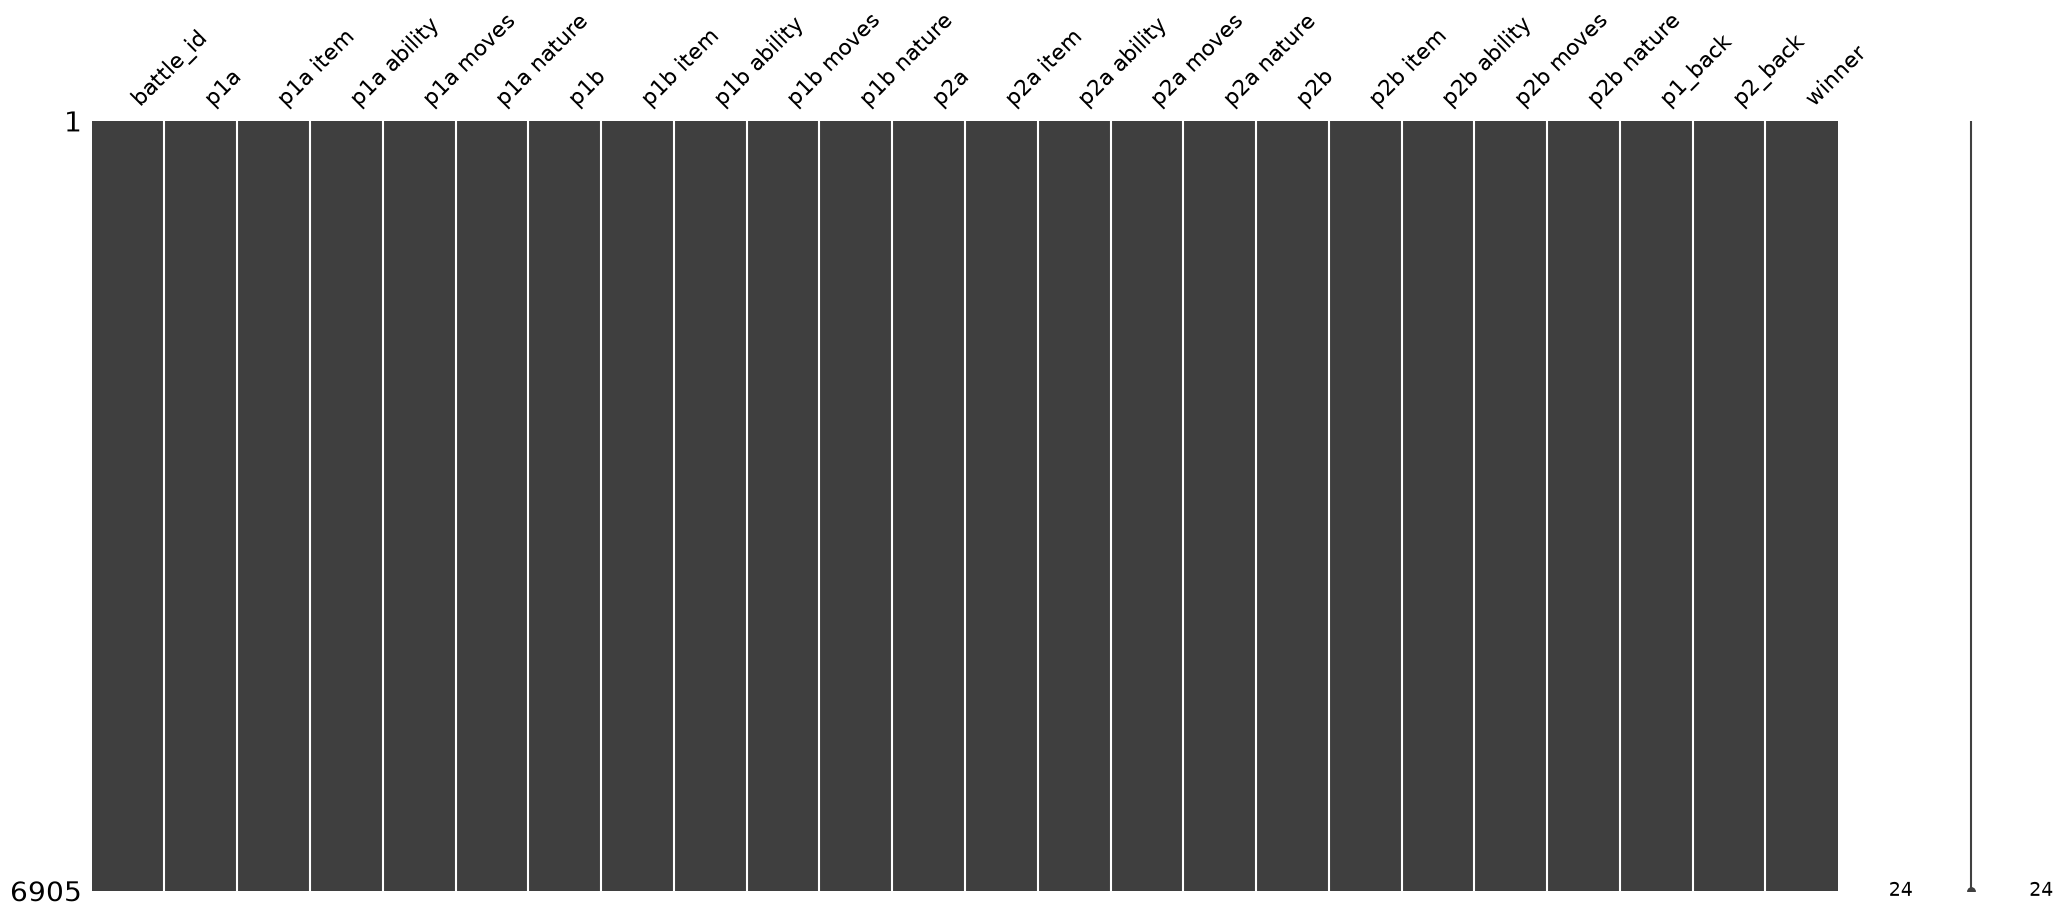

In [8]:
import missingno
missingno.matrix(processed_ma)

The full bars show that there no such values, however entries that have values like empty strings may technically count as valid and not be counted. We'll check for this in each column.

In [9]:
for col in processed_ma:
    if (processed_ma[col] == '').sum() != 0:                    # ignore columns that do not have any empty string values
        print(f'{col:15}{(processed_ma[col] == '').sum()}')

p1a item       52
p1a nature     5149
p1b item       35
p1b nature     5149
p2a item       41
p2a nature     5149
p2b item       35
p2b nature     5149


All 4 columns of leading Pokémon natures have a staggering 5,149 empty string values, almost 75% of the entire table. Obviously, just replacing all of these values with the next most common nature would not be a very accurate estimate at all. This issue will require a little more processing using context from other columns such as the related Pokémon species and/or it's held item.

Some leading Pokémon also have an empty item value, however this is not a problem, as Pokémon without a held item are legally viable in battles. Pokémon can't simply *not* have a nature, so empty strings should be considered invalid there.

Another thing we can look at is frequency of individual Pokémon species. This is especially important as it will help our models determine a "metagame" in learning which Pokémon are generally stronger or more impactful in battles. This example will look at most frequent leading Pokémon, as usually players will lead with their strongest / most impactful Pokémon to gain an early advantage.

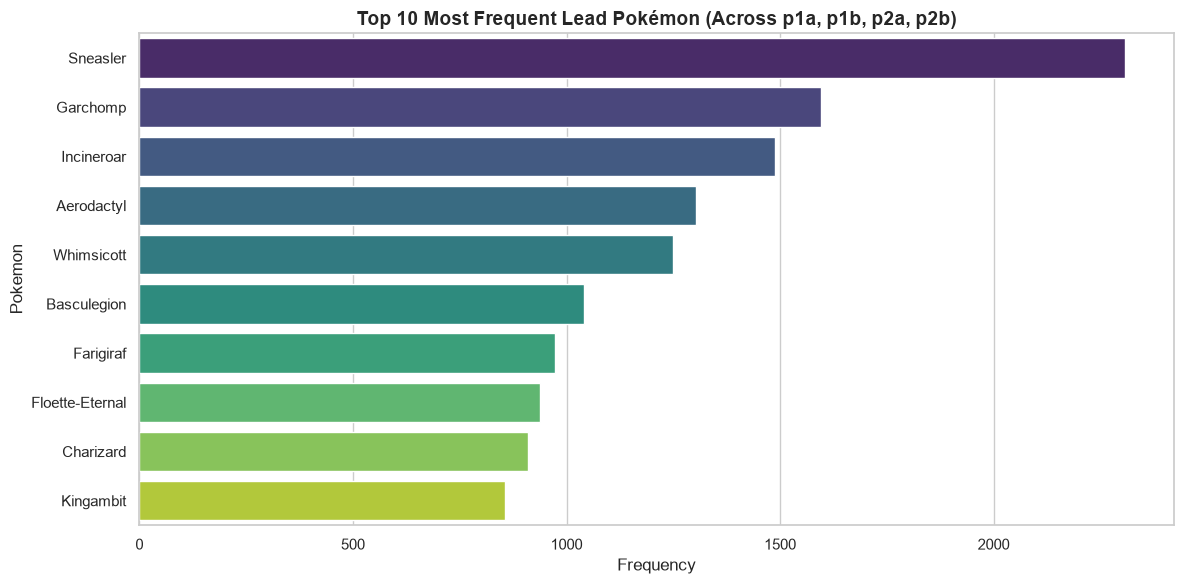

In [10]:
sb.set_theme(style='whitegrid')
cols = ['p1a', 'p1b', 'p2a', 'p2b']
combined_series = processed_ma[cols].melt()['value']                        # combine lead pokemon as specific position does not really matter (only care that they are leading)
top_10_combined = combined_series.value_counts().head(10).reset_index()
top_10_combined.columns = ['Pokemon', 'Count']

# Plot
plt.figure(figsize=(12, 6))
ax = sb.barplot(data=top_10_combined, x='Count', y='Pokemon', hue='Pokemon', palette='viridis', legend=False)
plt.title('Top 10 Most Frequent Lead Pokémon (Across p1a, p1b, p2a, p2b)', fontsize=14, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Pokemon', fontsize=12)
plt.tight_layout()
plt.show()

Balance / Outcome distribution is one more aspect worth looking at, as imbalance can affect our models during training. We need to look at things like the number of wins for both players and percentage of battles in each regulation. This will help us determine balancing among the two regulations and how we can use them when training / evaluating models. Start by importing the processed Reg. M-B file. We'll read the total amount of wins opposing players got in both tables, and what percent of total battles each regulation takes up.

In [11]:
processed_mb = pd.read_json('../' + config['dataset']['processed_path'] + config['dataset']['m_b'])
processed_mb.head(5)

,battle_id,p1a,p1a item,p1a ability,p1a moves,p1a nature,p1b,p1b item,p1b ability,p1b moves,...,p2a moves,p2a nature,p2b,p2b item,p2b ability,p2b moves,p2b nature,p1_back,p2_back,winner
0,gen9championsvgc2026regmb-2635876837,Blaziken,FocusSash,SpeedBoost,"[HeatWave, AuraSphere, Coaching, Protect]",Timid,Metagross,Metagrossite,ClearBody,"[IronHead, PsychicFangs, IcePunch, Protect]",...,"[DualWingbeat, Tailwind, RockSlide, Taunt]",Jolly,Sneasler,WhiteHerb,Unburden,"[FakeOut, Coaching, CloseCombat, GunkShot]",Adamant,"[Garchomp, Sinistcha, Floette-Eternal, Gyarados]","[Metagross, Garchomp, Whimsicott, Kingambit]",p1
1,gen9championsvgc2026regmb-2635674254,Whimsicott,FocusSash,Prankster,"[GigaDrain, Moonblast, Tailwind, Protect]",Timid,Floette-Eternal,Floettite,FlowerVeil,"[DazzlingGleam, Moonblast, LightofRuin, Protect]",...,"[IronHead, PsychicFangs, BrickBreak, Protect]",Adamant,Basculegion,ChoiceScarf,Adaptability,"[AquaJet, WaveCrash, LastRespects, FlipTurn]",Jolly,"[Mawile, Basculegion, Torkoal, Farigiraf]","[Garchomp, Hydreigon, Whimsicott, Sylveon]",p2
2,gen9championsvgc2026regmb-2635373041,Whimsicott,BrightPowder,Prankster,"[Moonblast, Tailwind, TrickRoom, HelpingHand]",Serious,Sneasler,FocusSash,Unburden,"[DireClaw, CloseCombat, FakeOut, Protect]",...,"[BraveBird, CloseCombat, Roost, Protect]",Jolly,Whimsicott,BrightPowder,Prankster,"[Moonblast, Tailwind, TrickRoom, HelpingHand]",Serious,"[Raichu, Azumarill, Politoed, Sinistcha]","[Sinistcha, Grimmsnarl, Incineroar, Froslass]",p1
3,gen9championsvgc2026regmb-2635629370,Charizard,CharizarditeY,SolarPower,"[HeatWave, AirSlash, AncientPower, Protect]",Timid,Sneasler,WhiteHerb,Unburden,"[CloseCombat, DireClaw, FakeOut, Feint]",...,"[Tailwind, LightScreen, Moonblast, Protect]",Timid,Annihilape,Leftovers,Defiant,"[Protect, RageFist, DrainPunch, BulkUp]",Adamant,"[Meganium, Incineroar, Empoleon, Dragonite]","[Charizard, Metagross, Maushold, Garchomp]",p1
4,gen9championsvgc2026regmb-2635374300,Raichu,RaichuniteY,LightningRod,"[ZapCannon, FocusBlast, NastyPlot, Protect]",Timid,Maushold,FocusSash,FriendGuard,"[Protect, FollowMe, SuperFang, Encore]",...,"[Tailwind, WeatherBall, Hurricane, Protect]",Modest,Basculegion,ChoiceScarf,Adaptability,"[WaveCrash, AquaJet, FlipTurn, LastRespects]",Jolly,"[Incineroar, Primarina, Corviknight, Garchomp]","[Archaludon, Sableye, Venusaur, Metagross]",p2


In [12]:
wins_ma = processed_ma['winner'].value_counts()
wins_mb = processed_mb['winner'].value_counts()
print(wins_ma, wins_mb, wins_ma + wins_mb, sep='\n')

winner
p1    3504
p2    3401
Name: count, dtype: int64
winner
p2    170
p1    154
Name: count, dtype: int64
winner
p1    3658
p2    3571
Name: count, dtype: int64


In [13]:
total_battles = len(processed_ma) + len(processed_mb)

ma_battles_percent = (len(processed_ma) / total_battles) * 100.0
mb_battles_percent = (len(processed_mb) / total_battles) * 100.0

print(f'# of Battles per Regulation:\n   M-A: {len(processed_ma)}\n   M-B: {len(processed_mb)}\n Total: {total_battles}')
print(f'% of Total Battles per Regulation:\n   M-A: {ma_battles_percent}\n   M-B: {mb_battles_percent}')

# of Battles per Regulation:
   M-A: 6905
   M-B: 324
 Total: 7229
% of Total Battles per Regulation:
   M-A: 95.51805228938996
   M-B: 4.481947710610043


Almost all of our battle data is from Regulation M-A. And of that 95%, ~75% has no valid Pokémon nature entry. Consequently, modeling a predictor for commonly used Pokémon natures will be one of our most important features and a big step to predicting winning matchups. Fortunately, from the second cell up, we see that both tables are quite balanced in terms of wins from opposing players, so the data does not seem imbalanced in that aspect. This will allow us to train and test on portions of the Regulation M-A table and validate on the Regulation M-B table.

# Sample Input / Output

As our models will analyze separate battles at a time, a sample input would consist of one entry from the processed JSON file. Here's an example of extracting an input from the processed Reg. M-A file:

In [22]:
processed_ma.iloc[0] # the sample instance as a DataFrame

battle_id                   gen9championsvgc2026regma-2600664326
p1a                                                   Aromatisse
p1a item                                               Leftovers
p1a ability                                            AromaVeil
p1a moves         [DazzlingGleam, HealPulse, Protect, TrickRoom]
p1a nature                                                      
p1b                                                      Lucario
p1b item                                             ChoiceScarf
p1b ability                                           InnerFocus
p1b moves         [FinalGambit, CloseCombat, IcePunch, Coaching]
p1b nature                                                      
p2a                                                    Charizard
p2a item                                           CharizarditeY
p2a ability                                           SolarPower
p2a moves            [Protect, HeatWave, WeatherBall, SolarBeam]
p2a nature               

In [48]:
# exporting the sample input to its own file
processed_ma.iloc[0].to_json('../' + config["dataset"]["sample_path"] + 'sample_input.json', indent=4)

Pokémon battles are generally won by having multiple forms of win conditions utilized in the same composition. Win conditions include things like having a good mix of offensive / defensive Pokémon, fast and slow Pokémon, Pokémon with good type synergy (fire > grass > water > fire), and Pokémon with good moveset coverage (moves that allow for speed control, positioning, or other forms of offensive / defensive setup). This one of the many reasons why VGC has an extremely high dimensionality constraint.

As an example for output, our models may be concerned with the number of moves each player lead has that allow for speed control. We can extract and analyze this "domain" (speed control) to help us better weigh which lead is likelier to win.

In [60]:
# read the sample instance
sample = pd.read_json('../' + config["dataset"]["sample_path"] + 'sample_input.json')

p1_lead_moves = list(sample['p1a moves']) + list(sample['p2a moves'])
p2_lead_moves = list(sample['p2a moves']) + list(sample['p2b moves'])

# pool of speed control moves
speed_control = ['Tailwind', 'FakeOut', 'TrickRoom']

p1_speed_flags = {
    f"p1_has_{m}": any(m in p1_lead_moves for m in [m]) for m in speed_control
}
p2_speed_flags = {
    f"p2_has_{m}": any(m in p2_lead_moves for m in [m]) for m in speed_control
}

p1_score = sum(p1_speed_flags.values())
p2_score = sum(p2_speed_flags.values())

analysis = {
    'battle_id': sample['battle_id'].unique()[0],
    'p1_has_fakeout': int('FakeOut' in p1_lead_moves),
    'p1_has_tailwind': int('Tailwind' in p1_lead_moves),
    'p1_has_trickroom': int('TrickRoom' in p1_lead_moves),
    'p2_has_fakeout': int('FakeOut' in p2_lead_moves),
    'p2_has_tailwind': int('Tailwind' in p2_lead_moves),
    'p2_has_trickroom': int('TrickRoom' in p2_lead_moves),
    'p1_speed_control_score': p1_score,
    'p2_speed_control_score': p2_score,
    'p1_has_speed_advantage': int(p1_score > p2_score),
}

print(f'P1 Lead Moves:\n\t{p1_lead_moves}\nP2 Lead Moves:\n\t{p2_lead_moves}')
analysis_df = pd.DataFrame([analysis]).T.rename(columns={0: 'Extracted Value'})
analysis_df

P1 Lead Moves:
	['DazzlingGleam', 'HealPulse', 'Protect', 'TrickRoom', 'Protect', 'HeatWave', 'WeatherBall', 'SolarBeam']
P2 Lead Moves:
	['Protect', 'HeatWave', 'WeatherBall', 'SolarBeam', 'Protect', 'EarthPower', 'DarkPulse', 'DracoMeteor']


,Extracted Value
battle_id,gen9championsvgc2026regma-2600664326
p1_has_fakeout,0
p1_has_tailwind,0
p1_has_trickroom,1
p2_has_fakeout,0
p2_has_tailwind,0
p2_has_trickroom,0
p1_speed_control_score,1
p2_speed_control_score,0
p1_has_speed_advantage,1


In [61]:
# output the feature analysis as a JSON for later use
analysis_df.to_json('../' + config["dataset"]["sample_path"] + 'sample_output.json', indent=4)

This example shows player 1 has been found to have one method of speed control based off the pool (`speed_control`) whereas player 2 has none. So player 1's speed control "score" ranks higher than player 2's, and therefore player 1 is determined to have speed advantage.